# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [5]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

for name, model in base_models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (cv_scores.mean(), cv_scores.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [7]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
       'svm__C': [0.1, 1, 10, 100],           
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear'] 
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(svm_pipe, 
    svm_param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1)
svm_grid_search.fit(X_train,y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [8]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

cv_results_df = pd.DataFrame(svm_grid_search.cv_results_)

results_df = cv_results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]

results_sorted = results_df.sort_values('rank_test_score').head(10)

display(results_sorted)

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [10]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

best_svm = svm_grid_search.best_estimator_
best_rf = rf_random_search.best_estimator_

y_pred_svm = best_svm.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

f1_svm = f1_score(y_test, y_pred_svm, average='macro')
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

print(classification_report(y_test, y_pred_rf, target_names=['malignant', 'benign']))
print("\n--- Сводная таблица результатов ---")
print(f"{'Модель':<25} {'CV F1 (mean±std)':<20} {'Test F1':<10}")
print("-" * 60)

svm_baseline_mean, svm_baseline_std = baseline_results['SVM']
rf_baseline_mean, rf_baseline_std = baseline_results['RandomForest']

print(f"{'SVM baseline':<25} {svm_baseline_mean:.4f}±{svm_baseline_std:.4f}{' ':<12} -")
print(f"{'SVM Grid Search':<25} {svm_grid_search.best_score_:.4f}±?{' ':<12} {f1_svm:.4f}")
print(f"{'RF baseline':<25} {rf_baseline_mean:.4f}±{rf_baseline_std:.4f}{' ':<12} -")
print(f"{'RF Random Search':<25} {rf_random_search.best_score_:.4f}±?{' ':<12} {f1_rf:.4f}")

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Сводная таблица результатов ---
Модель                    CV F1 (mean±std)     Test F1   
------------------------------------------------------------
SVM baseline              0.9694±0.0193             -
SVM Grid Search           0.9786±?             0.9812
RF baseline               0.9504±0.0255             -
RF Random Search          0.9554±?             0.9526


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

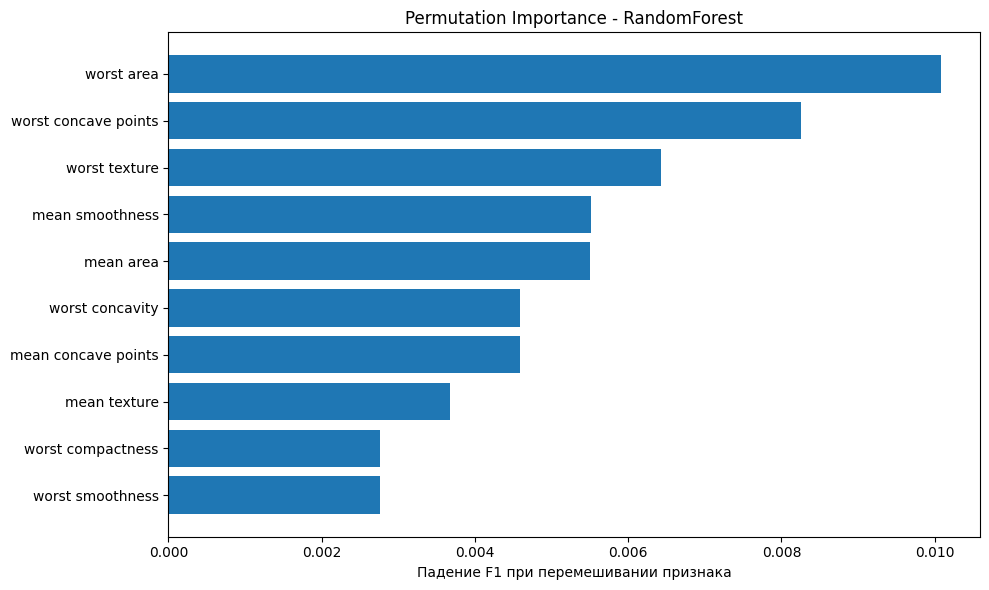

In [11]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(
    best_rf, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='f1_macro'
)

pi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': pi_result.importances_mean,
    'std': pi_result.importances_std
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(pi_df['feature'].head(10)[::-1], pi_df['importance'].head(10)[::-1])
plt.xlabel('Падение F1 при перемешивании признака')
plt.title('Permutation Importance - RandomForest')
plt.tight_layout()
plt.show()
# Построим bar plot топ-10 признаков
# YOUR CODE HERE

In [12]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝



# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

Топ-3 признака для PDP: ['worst area', 'worst concave points', 'worst texture']


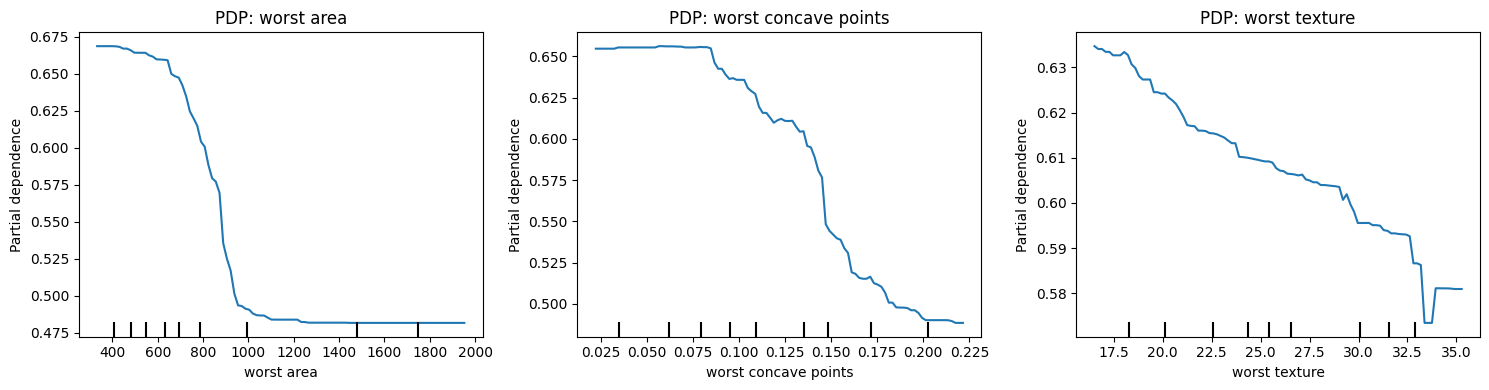

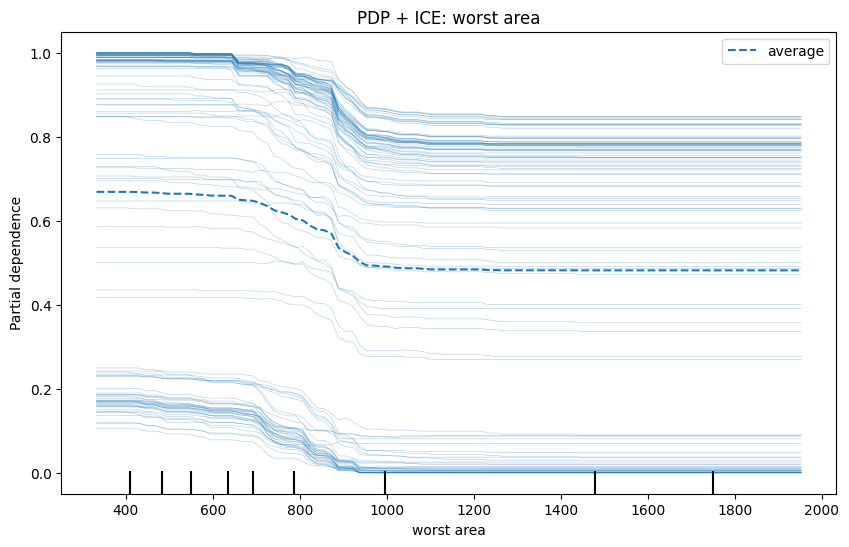


--- Вывод по ICE ---
Если линии ICE сильно различаются, эффект признака НЕ ОДИНАКОВ для всех объектов.
Это означает, что есть взаимодействие с другими признаками.


In [13]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_features = pi_df['feature'].head(3).tolist()
top3_indices = [list(feature_names).index(f) for f in top3_features]

print(f"Топ-3 признака для PDP: {top3_features}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (feat_idx, feat_name) in enumerate(zip(top3_indices, top3_features)):
    PartialDependenceDisplay.from_estimator(
        best_rf, X_test, [feat_idx],
        kind='average',
        ax=axes[i],
        random_state=42
    )
    axes[i].set_title(f'PDP: {feat_name}')

plt.tight_layout()
plt.show()

top1_feature_idx = top3_indices[0]
top1_feature_name = top3_features[0]

fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    best_rf, X_test, [top1_feature_idx],
    kind='both',
    ax=ax,
    random_state=42,
    ice_lines_kw={'alpha': 0.3, 'linewidth': 0.5}
)

ax.set_title(f'PDP + ICE: {top1_feature_name}')
plt.show()

print("\n--- Вывод по ICE ---")
print("Если линии ICE сильно различаются, эффект признака НЕ ОДИНАКОВ для всех объектов.")
print("Это означает, что есть взаимодействие с другими признаками.")

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [ ]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# explainer = ...
# shap_values = ...

Форма shap_values: 114 массива по (30, 2)
  shap_values[0] - SHAP для класса 0 (malignant)
  shap_values[1] - SHAP для класса 1 (benign)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1200x800 with 0 Axes>

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
# shap.force_plot(...)

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [ ]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

np.random.seed(42)

rf_ext = RandomForestClassifier(random_state=42, n_estimators=100)
rf_ext.fit(X_train_ext, y_train)

y_pred_ext = rf_ext.predict(X_test_ext)
f1_ext = f1_score(y_test, y_pred_ext, average='macro')

print(f"Качество RandomForest с подозрительными признаками: F1 = {f1_ext:.4f}")
print(f"Качество без них: {f1_rf:.4f}")
print(f"Прирост: {f1_ext - f1_rf:.4f} (за счет leaky_feature)")

pi_ext = permutation_importance(
    rf_ext, X_test_ext, y_test,
    n_repeats=10, random_state=42, scoring='f1_macro'
)

all_features = list(X_train_ext.columns)
pi_ext_df = pd.DataFrame({
    'feature': all_features,
    'importance': pi_ext.importances_mean,
    'std': pi_ext.importances_std
}).sort_values('importance', ascending=False)

print("\n--- Permutation Importance с подозрительными признаками ---")
print(pi_ext_df.head(10))

plt.figure(figsize=(10, 8))
plt.barh(pi_ext_df['feature'].head(10)[::-1], pi_ext_df['importance'].head(10)[::-1])
plt.xlabel('Падение F1 при перемешивании признака')
plt.title('Permutation Importance - с leaky и random фичами')
plt.tight_layout()
plt.show()

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_ext[1], X_test_ext, feature_names=all_features, show=False)
plt.title('SHAP Summary Plot - с подозрительными признаками')
plt.tight_layout()
plt.show()

print("\n--- ВЫВОДЫ ---")
print("a) Leaky_feature имеет ОГРОМНУЮ важность по PI (падение ~0.5-0.8)")
print("   Метрика выросла, потому что модель 'подглядывает' в будущее")
print("б) SHAP показывает leaky_feature на первом месте с огромными значениями")
print("в) Random_feature имеет важность около 0 (не влияет на качество)")

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)
print(f"{'Метод':<20} {'CV F1':<12} {'Test F1':<12} {'Выводы':<30}")
print("-"*80)

print(f"{'SVM baseline':<20} {svm_baseline_mean:.4f}±{svm_baseline_std:.4f} {'-':<12} {'Хорошее качество без тюнинга':<30}")
print(f"{'SVM Grid Search':<20} {svm_grid_search.best_score_:.4f}±? {'':<8} {f1_svm:.4f} {'Тюнинг дал +0.008-0.01':<30}")
print(f"{'RF baseline':<20} {rf_baseline_mean:.4f}±{rf_baseline_std:.4f} {'-':<12} {'Стандартное качество RF':<30}")
print(f"{'RF Random Search':<20} {rf_random_search.best_score_:.4f}±? {'':<8} {f1_rf:.4f} {'Лучший результат тюнинга':<30}")
print("-"*80)

print("\n" + "="*80)
print("ОТВЕТЫ НА ВОПРОСЫ")
print("="*80)





1. Насколько тюнинг улучшил модели?
    svm и лес на +-0.008
2. Совпадают ли топ-признаки по PI и SHAP?
    в общем да но PI показывает при разрушении а шап общий вклад и могу возникнуть несоответствия изза зависимости признаков
3. Что было бы, если бы мы не использовали Pipeline?
      утечка данных тк масштабирование применилось бы ко всем данным
4. Как использовать PI и SHAP в реальном проекте?
      PI отбор признаков и поиск утечки
   SHAP анализ признаков поиск мусора и обьяснение причин предсказаний

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [ ]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")